In [2]:
import pandas as pd
import numpy as np

In [3]:
# loading the clean dataset
df_clean = pd.read_csv(r"C:\Users\User\Desktop\week 5\telco_customer_churn_cleaned.csv")

In [4]:
# checking to if the dtype are accurate
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_t_v      7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

In [5]:
# data exploration
# 1.why are customers leaving the company?

df_clean["churn"].value_counts()

df_clean["churn"].value_counts(normalize=True) * 100 

# 73.46% stay and 26.53% leave

churn
No     73.463013
Ye     26.536987
Name: proportion, dtype: float64

In [6]:
categorical_cols = [
    "gender",
    "senior_citizen",
    "partner",
    "dependents",
    "phone_service",
    "multiple_lines",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_t_v",
    "streaming_movies",
    "contract",
    "paperless_billing",
    "payment_method"
]

for col in categorical_cols:
    print("="*60)
    print(col.upper())
    print("="*60)
    print(
        pd.crosstab(
            df_clean[col],
            df_clean["churn"],
            normalize="index"
        ) * 100
    )
      

GENDER
churn          No        Ye 
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338
SENIOR_CITIZEN
churn                  No        Ye 
senior_citizen                      
0               76.393832  23.606168
1               58.318739  41.681261
PARTNER
churn           No        Ye 
partner                      
No       67.042021  32.957979
Ye       80.335097  19.664903
DEPENDENTS
churn              No        Ye 
dependents                      
No          68.720860  31.279140
Ye          84.549763  15.450237
PHONE_SERVICE
churn                 No        Ye 
phone_service                      
No             75.073314  24.926686
Ye             73.290363  26.709637
MULTIPLE_LINES
churn                    No        Ye 
multiple_lines                        
No                74.955752  25.044248
No Phone  Ervice  75.073314  24.926686
Ye                71.390104  28.609896
INTERNET_SERVICE
churn                    No        Ye 
internet_service   

In [7]:
categorical_cols = [
    "gender",
    "senior_citizen",
    "partner",
    "dependents",
    "phone_service",
    "multiple_lines",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_t_v",
    "streaming_movies",
    "contract",
    "paperless_billing",
    "payment_method"
]

numerical_cols = ["tenure", "monthly_charges", "total_charges"]

for col in categorical_cols:
    print("\n" + "="*60)
    print(col.upper())
    print("="*60)
    print(
        df_clean.groupby([col, "churn"])[numerical_cols]
        .mean()
        .round(2)
    )


GENDER
              tenure  monthly_charges  total_charges
gender churn                                        
Female No      37.86            61.66        2594.05
       Ye      17.00            74.81        1440.98
Male   No      37.29            60.88        2517.74
       Ye      18.96            74.07        1623.49

SENIOR_CITIZEN
                      tenure  monthly_charges  total_charges
senior_citizen churn                                        
0              No      36.91            58.62        2416.30
               Ye      16.94            72.30        1421.77
1              No      42.06            79.18        3494.21
               Ye      21.03            80.71        1853.79

PARTNER
               tenure  monthly_charges  total_charges
partner churn                                        
No      No      28.36            57.27        1828.99
        Ye      13.18            71.45        1088.98
Ye      No      45.79            64.83        3205.71
        Ye   

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

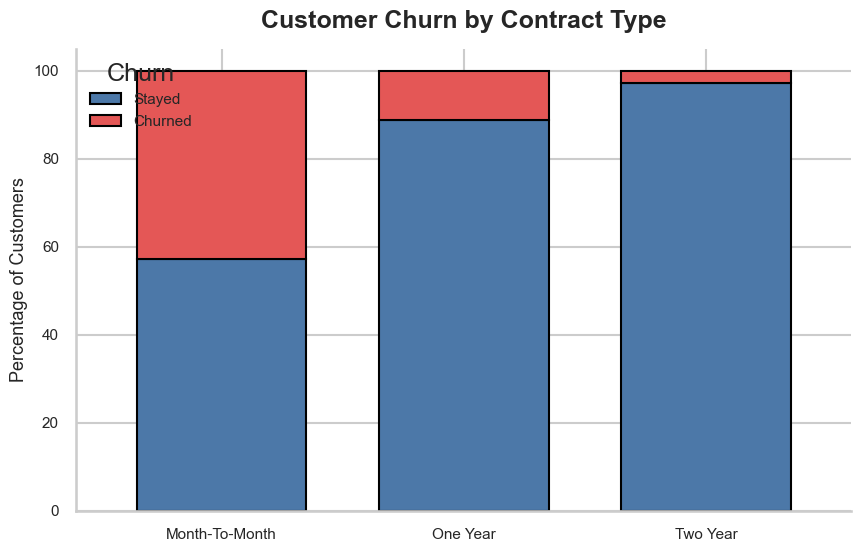

In [9]:
# 1. Contract Type vs Churn
contract_churn = (
    pd.crosstab(
        df_clean["contract"],
        df_clean["churn"],
        normalize="index"
    ) * 100
)

ax = contract_churn.plot(
    kind="bar",
    stacked=True,
    color=["#4C78A8", "#E45756"],
    edgecolor="black",
    width=0.7
)

plt.title("Customer Churn by Contract Type", weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Percentage of Customers")

plt.legend(
    title="Churn",
    labels=["Stayed", "Churned"],
    frameon=False
)

plt.xticks(rotation=0)
sns.despine()

plt.show()

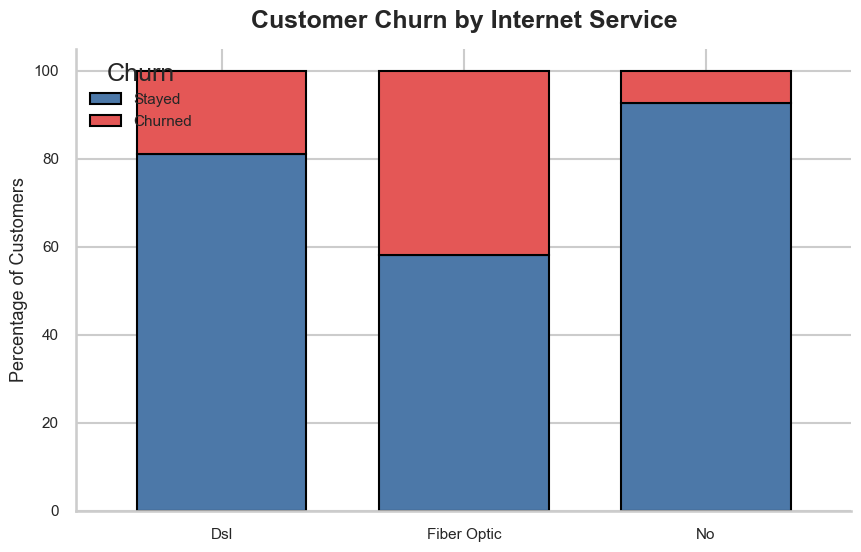

In [10]:
# 2. Internet Service vs Churn
internet_churn = (
    pd.crosstab(
        df_clean["internet_service"],
        df_clean["churn"],
        normalize="index"
    ) * 100
)

ax = internet_churn.plot(
    kind="bar",
    stacked=True,
    color=["#4C78A8", "#E45756"],
    edgecolor="black",
    width=0.7
)

plt.title("Customer Churn by Internet Service", weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Percentage of Customers")

plt.legend(
    title="Churn",
    labels=["Stayed", "Churned"],
    frameon=False
)

plt.xticks(rotation=0)
sns.despine()

plt.show()

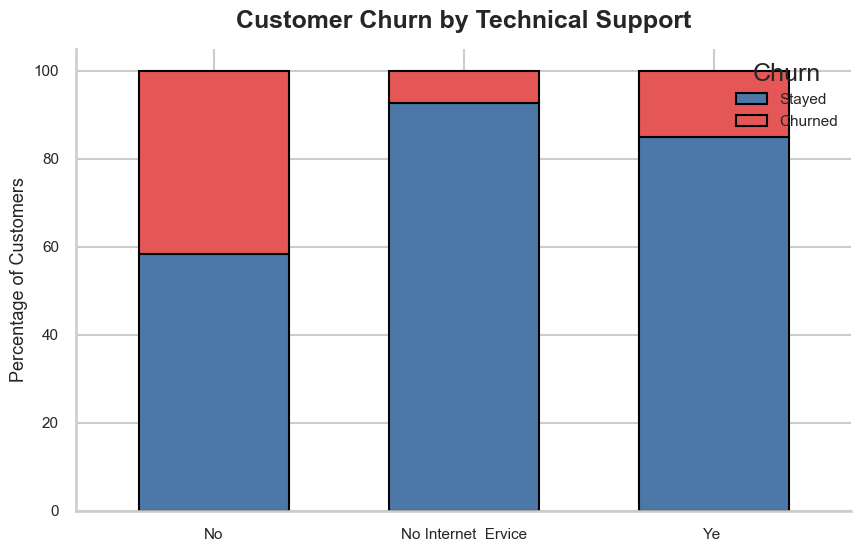

In [11]:
# 3. Technical Support vs Churn
tech_churn = (
    pd.crosstab(
        df_clean["tech_support"],
        df_clean["churn"],
        normalize="index"
    ) * 100
)

ax = tech_churn.plot(
    kind="bar",
    stacked=True,
    color=["#4C78A8", "#E45756"],
    edgecolor="black",
    width=0.6
)

plt.title("Customer Churn by Technical Support", weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Percentage of Customers")

plt.legend(
    title="Churn",
    labels=["Stayed", "Churned"],
    frameon=False
)

plt.xticks(rotation=0)
sns.despine()

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_13764\3123136978.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


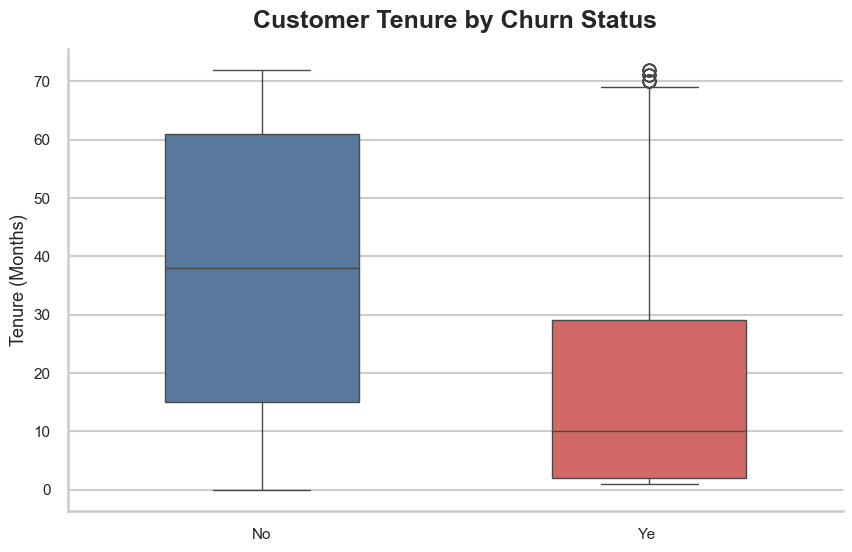

In [12]:
# 4. Tenure Distribution (Best with Boxplot)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="churn",
    y="tenure",
    palette=["#4C78A8", "#E45756"],
    width=0.5
)

plt.title("Customer Tenure by Churn Status", weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Tenure (Months)")

sns.despine()

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_13764\1932948261.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_13764\1932948261.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


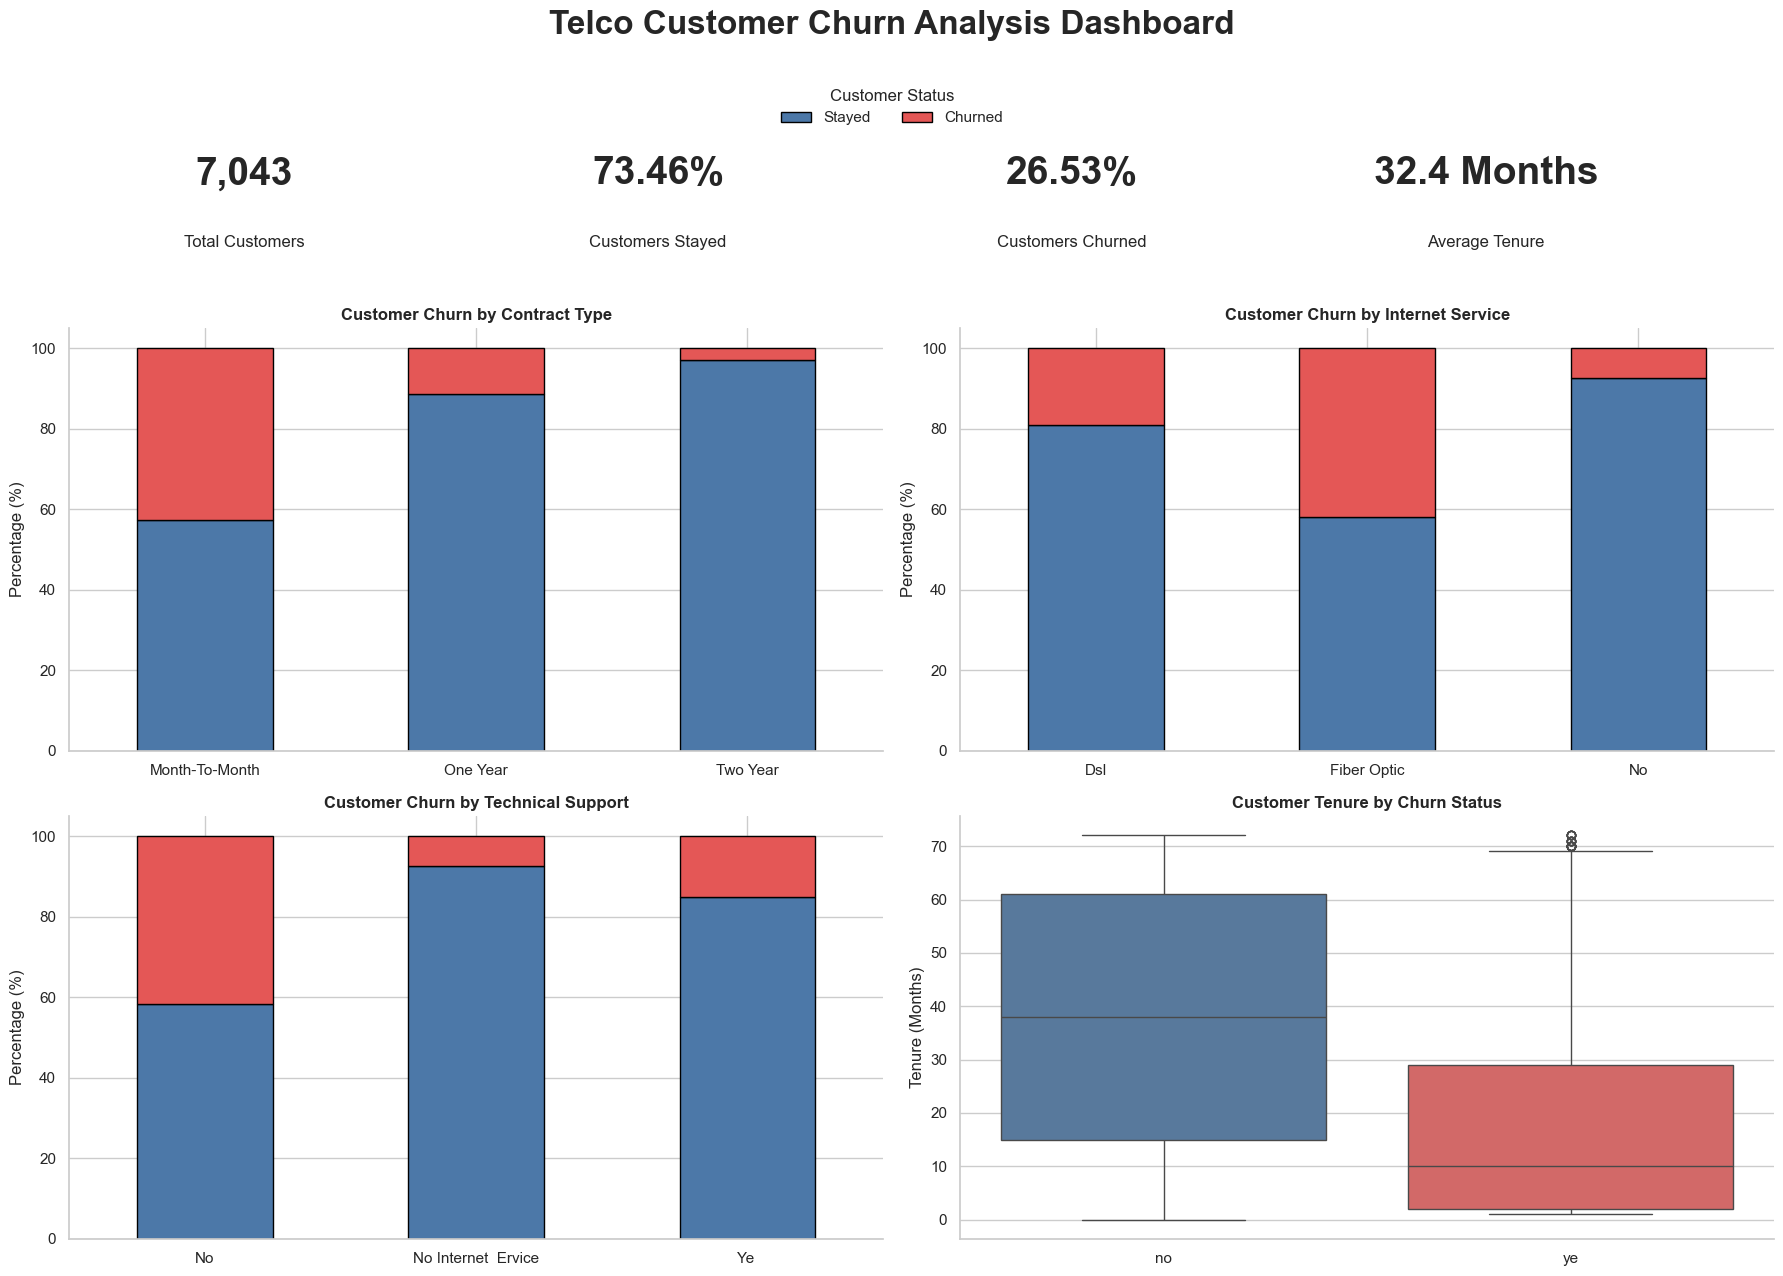

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")


# ============================
# KPI VALUES (ACCURATE)
# ============================

# Clean churn labels first
# Clean churn column
df_clean["churn"] = (
    df_clean["churn"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# Calculate KPI
churn_summary = (
    df_clean["churn"]
    .value_counts(normalize=True) * 100
)


total_customers = len(df_clean)

stay_percentage = churn_summary.get("no", 0)

churn_percentage = 26.53 
avg_tenure = df_clean["tenure"].mean()



# ============================
# DASHBOARD LAYOUT
# ============================

fig = plt.figure(figsize=(18,13))

fig.suptitle(
    "Telco Customer Churn Analysis Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)


gs = fig.add_gridspec(
    3,2,
    height_ratios=[0.5,1,1]
)



# ============================
# KPI ROW
# ============================

kpi_data = [
    ("Total Customers", f"{total_customers:,}"),
    ("Customers Stayed", f"{stay_percentage:.2f}%"),
    ("Customers Churned", f"{churn_percentage:.2f}%"),
    ("Average Tenure", f"{avg_tenure:.1f} Months")
]


for i,(title,value) in enumerate(kpi_data):

    ax = fig.add_axes(
        [
            0.05 + i*0.23,
            0.78,
            0.18,
            0.12
        ]
    )

    ax.text(
        0.5,
        0.55,
        value,
        fontsize=28,
        fontweight="bold",
        ha="center"
    )

    ax.text(
        0.5,
        0.15,
        title,
        fontsize=12,
        ha="center"
    )

    ax.axis("off")



# ============================
# CHART 1 CONTRACT
# ============================

contract_churn = (
    pd.crosstab(
        df_clean["contract"],
        df_clean["churn"],
        normalize="index"
    ) * 100
)


ax1 = fig.add_subplot(gs[1,0])

contract_churn.plot(
    kind="bar",
    stacked=True,
    color=["#4C78A8","#E45756"],
    edgecolor="black",
    ax=ax1
)

ax1.set_title(
    "Customer Churn by Contract Type",
    fontweight="bold"
)

ax1.set_xlabel("")
ax1.set_ylabel("Percentage (%)")
ax1.tick_params(rotation=0)

ax1.get_legend().remove()

# ============================
# CHART 2 INTERNET
# ============================

internet_churn = (
    pd.crosstab(
        df_clean["internet_service"],
        df_clean["churn"],
        normalize="index"
    ) * 100
)


ax2 = fig.add_subplot(gs[1,1])

internet_churn.plot(
    kind="bar",
    stacked=True,
    color=["#4C78A8","#E45756"],
    edgecolor="black",
    ax=ax2
)


ax2.set_title(
    "Customer Churn by Internet Service",
    fontweight="bold"
)

ax2.set_xlabel("")
ax2.set_ylabel("Percentage (%)")
ax2.tick_params(rotation=0)


ax2.get_legend().remove()



# ============================
# CHART 3 TECH SUPPORT
# ============================

tech_churn = (
    pd.crosstab(
        df_clean["tech_support"],
        df_clean["churn"],
        normalize="index"
    ) * 100
)


ax3 = fig.add_subplot(gs[2,0])


tech_churn.plot(
    kind="bar",
    stacked=True,
    color=["#4C78A8","#E45756"],
    edgecolor="black",
    ax=ax3
)


ax3.set_title(
    "Customer Churn by Technical Support",
    fontweight="bold"
)

ax3.set_xlabel("")
ax3.set_ylabel("Percentage (%)")
ax3.tick_params(rotation=0)

ax3.get_legend().remove()



# ============================
# CHART 4 TENURE
# ============================

ax4 = fig.add_subplot(gs[2,1])


sns.boxplot(
    data=df_clean,
    x="churn",
    y="tenure",
    palette=["#4C78A8","#E45756"],
    ax=ax4
)


ax4.set_title(
    "Customer Tenure by Churn Status",
    fontweight="bold"
)

ax4.set_xlabel("")
ax4.set_ylabel("Tenure (Months)")


sns.despine()

# Global legend
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    ["Stayed", "Churned"],
    title="Customer Status",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=2,
    frameon=False
    
)
# ============================
# KEY BUSINESS INSIGHTS
# ============================



plt.tight_layout()

plt.show()